In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


In [2]:
plt.style.use('/home/joliveira/Documents/franck-hertz/joao.mplstyle')
# --- DEFINIÇÃO DO TEMA GLOBAL USANDO rcParams ---
plt.rcParams['figure.figsize'] = (20, 12) # Define o tamanho da figura para 10x6 polegadas
plt.rcParams['font.size'] = 14           # Define o tamanho da fonte geral como 14
plt.rcParams['axes.titlesize'] = 25      # Tamanho da fonte do título
plt.rcParams['axes.labelsize'] = 20      # Tamanho da fonte dos rótulos dos eixos
plt.rcParams['axes.grid'] = True        # Habilita/desabilita a grade em todos os gráficos
plt.rcParams['grid.linestyle'] = '-'      # Estilo da grade: tracejado
plt.rcParams['grid.alpha'] = 0.6         # Transparência da grade
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['savefig.dpi'] = 700        # Alta resolução para salvar as figuras
plt.rcParams['lines.linestyle'] = '-'    # Linha sólida
plt.rcParams['lines.linewidth'] = 3   # Espessura da linha
# plt.rcParams['figure.facecolor'] = 'none'   # Fundo da figura transparente
# plt.rcParams['axes.facecolor']   = 'none'   # Fundo dos eixos transparente
# plt.rcParams['savefig.facecolor'] = 'none'  # Ao salvar, mantém transparente
# plt.rcParams['savefig.transparent'] = True  # Salva figuras com fundo transparente
plt.rcParams['xtick.labelsize'] = 16    # Tamanho dos rótulos do eixo x
plt.rcParams['ytick.labelsize'] = 16    # Tamanho dos rótulos do eixo y
# ---------------------------------------------------

Missing colon in file '/home/joliveira/Documents/franck-hertz/joao.mplstyle', line 617 ('view raw')
Missing colon in file '/home/joliveira/Documents/franck-hertz/joao.mplstyle', line 618 ('matplotlibrc hosted with ❤ by GitHub')


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.signal import find_peaks

def gerar_graficos_franck_hertz(
    caminho_excel,
    caminho_dados,
    caminho_saida,
    tipo='V1',
    temperatura=150,
    fator_dist=4,
    fator_prom=0.06,
    mostrar_deltas=False  # ← NOVO PARÂMETRO (#1)
):
    """
    Gera e salva gráficos do experimento de Franck-Hertz.

    Parâmetros:
        caminho_excel (str): Caminho do arquivo Excel com fatores de escala.
        caminho_dados (str): Caminho da pasta contendo os arquivos .txt.
        caminho_saida (str): Pasta onde os gráficos serão salvos.
        tipo (str): 'V1', 'V2' ou 'V4' — define qual conjunto de medidas usar.
        temperatura (int|str): Temperatura usada nos nomes dos arquivos.
        fator_dist (float): Multiplicador do espaçamento mínimo entre vales.
        fator_prom (float): Fator de proeminência mínima relativa.
        mostrar_deltas (bool): Se True, exibe anotações de ΔV entre vales consecutivos.
    """

    # === Lê o arquivo Excel ===
    df = pd.read_excel(caminho_excel)
    display(df.head())

    # === Configuração conforme o tipo ===
    if tipo.upper() == 'V1':
        medidas = range(1, 5)
        limite_potencial = 30
        coluna_v = "V1 [Volts]"
        titulo_base = "Curvas Corrente por Tensão (Variando V1)"
    elif tipo.upper() == 'V2':
        medidas = range(5, 9)
        limite_potencial = 22
        coluna_v = "V2 [Volts]"
        titulo_base = "Curvas Corrente por Tensão (Variando V2)"
    elif tipo.upper() == 'V4':
        medidas = range(9, 13)
        limite_potencial = 24
        coluna_v = "V4 [Volts]"
        titulo_base = "Curvas Corrente por Tensão (Variando V4)"
    else:
        raise ValueError("tipo deve ser 'V1', 'V2' ou 'V4'.")

    # === Lê e processa os arquivos de dados ===
    dados_medidas = []
    for medida in medidas:
        nome_arquivo = f"m{medida}-m-e-T_{temperatura}.txt"
        caminho_arquivo = os.path.join(caminho_dados, nome_arquivo)

        if not os.path.exists(caminho_arquivo):
            print(f"⚠️ Arquivo não encontrado: {caminho_arquivo}")
            continue

        df_dados = pd.read_csv(
            caminho_arquivo,
            sep=r"\s+",
            header=None,
            names=["Potencial (V)", "Corrente (uA)"]
        )

        linha_info = df.loc[df["Medida"] == medida]
        escala = linha_info["Escala "].values[0]
        valor_v = linha_info[coluna_v].values[0]

        df_dados["Corrente (uA)"] *= escala
        df_dados = df_dados[df_dados["Potencial (V)"] <= limite_potencial].reset_index(drop=True)
        dados_medidas.append((valor_v, df_dados))

    # === Normalização global ===
    todas_correntes = np.concatenate([df["Corrente (uA)"].values for _, df in dados_medidas])
    I_min, I_max = todas_correntes.min(), todas_correntes.max()
    print(f"Mínimo global: {I_min:.9f}, Máximo global: {I_max:.9f}")

    # === Configurações visuais ===
    marcadores = ["o", "s", "^", "D", "v", "P", "*"]
    marcador_vale = "X"
    cor_vale = "red"

    # === Função interna de plotagem ===
    def plotar_grafico(dados_medidas, mostrar_vales=True):
        plt.figure(figsize=(20, 12))

        for i, (valor_v, df_dados) in enumerate(dados_medidas):
            df_dados["Corrente Normalizada"] = (df_dados["Corrente (uA)"] - I_min) / (I_max - I_min)
            V = df_dados["Potencial (V)"].to_numpy()
            I = df_dados["Corrente Normalizada"].to_numpy()

            # Suavização (média móvel)
            I_suave = np.convolve(I, np.ones(5)/5, mode='same')

            dist = int(fator_dist * max(20, len(V)//50) * 1.75)
            prom = fator_prom * (I.max() - I.min())

            vales, _ = find_peaks(-I_suave, distance=dist, prominence=prom)
            vales = vales[V[vales] >= 4.9]

            print(f"Medida {i+1} ({coluna_v}={valor_v:.1f} V): {len(vales)} vales encontrados")

            marcador = marcadores[i % len(marcadores)]
            plt.plot(
                V, I,
                label=f"{coluna_v.split()[0]} = {valor_v:.1f} V",
                marker=marcador,
                markevery=50,
                linewidth=2.5,
                markersize=10
            )

            # --- Marcação e anotações ---
            if mostrar_vales and len(vales) > 0:
                plt.scatter(
                    V[vales], I[vales],
                    color=cor_vale,
                    s=130,
                    marker=marcador_vale,
                    edgecolor="black",
                    linewidth=1.3,
                    zorder=5
                )

                # === Anotação do potencial em cada vale ===
                for j, idx in enumerate(vales):
                    plt.text(
                        V[idx],
                        I[idx] * 0.7,  # levemente abaixo do ponto
                        f"{V[idx]:.2f} V",
                        fontsize=12,
                        color="blue",
                        ha="center",
                        va="top",
                        fontweight="bold",
                        bbox=dict(facecolor="white", alpha=0.8, boxstyle="round,pad=0.2")
                    )

                # === Mostrar ΔV apenas se o parâmetro for True ===
                if mostrar_deltas and len(vales) > 1:  # ← NOVO BLOCO CONDICIONAL (#2)
                    for j in range(len(vales) - 1):
                        x1, x2 = V[vales[j]], V[vales[j + 1]]
                        y1, y2 = I[vales[j]], I[vales[j + 1]]
                        delta_V = x2 - x1
                        x_medio = (x1 + x2) / 2
                        y_medio = (y1 + y2) / 2

                        plt.text(
                            x_medio,
                            y_medio * 1.3,
                            f"ΔV = {delta_V:.2f} V",
                            fontsize=13,
                            color="black",
                            ha="center",
                            va="bottom",
                            fontweight="bold",
                            bbox=dict(facecolor="white", alpha=0.8, boxstyle="round,pad=0.2")
                        )

        plt.xlabel("Potencial (Volts)")
        plt.ylabel("Corrente Normalizada")
        titulo = f"{titulo_base} — {temperatura}°C"
        if mostrar_vales:
            titulo += " — com vales"
            if mostrar_deltas:
                titulo += " e ΔV"
        plt.title(titulo)

        plt.yscale('log')
        plt.ylim(bottom=1e-5)
        plt.grid(True, which='both', linestyle='--', linewidth=0.7)
        plt.legend(
            title=f"Valores de {coluna_v.split()[0]} (Volts)",
            fontsize=14,
            title_fontsize=16,
            facecolor="white",
            framealpha=1.0
        )
        plt.tight_layout()

        os.makedirs(caminho_saida, exist_ok=True)
        sufixo = "com_vales" if mostrar_vales else "sem_vales"
        nome_arquivo = f"grafico_{tipo.upper()}_{temperatura}C_{sufixo}_saida.png"
        caminho_figura = os.path.join(caminho_saida, nome_arquivo)
        plt.savefig(caminho_figura, dpi=300)
        print(f"💾 Gráfico salvo em: {caminho_figura}")

        plt.show()

    print(f"\n=== Gráfico COM vales ({tipo.upper()}, {temperatura}°C) ===")
    plotar_grafico(dados_medidas, mostrar_vales=True)

    print(f"\n=== Gráfico SEM vales ({tipo.upper()}, {temperatura}°C) ===")
    plotar_grafico(dados_medidas, mostrar_vales=False)


,Medida,V1 [Volts],V2 [Volts],V4 [Volts],Escala
0,1,6.08,6.19,0.5,3.000000e-07
1,2,5.60,6.19,0.5,1.000000e-07
2,3,5.00,6.19,0.5,1.000000e-08
3,4,4.60,6.19,0.5,1.000000e-08
4,5,6.11,6.22,0.5,1.000000e-06


Mínimo global: 0.000000000, Máximo global: 0.000077700

=== Gráfico COM vales (V1, 160°C) ===
Medida 1 (V1 [Volts]=6.1 V): 4 vales encontrados
Medida 2 (V1 [Volts]=5.6 V): 4 vales encontrados
Medida 3 (V1 [Volts]=5.0 V): 5 vales encontrados
Medida 4 (V1 [Volts]=4.6 V): 5 vales encontrados


/tmp/ipykernel_4079/1193547696.py:185: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


💾 Gráfico salvo em: Resultados/grafico_V1_160C_com_vales_saida.png



=== Gráfico SEM vales (V1, 160°C) ===
Medida 1 (V1 [Volts]=6.1 V): 4 vales encontrados
Medida 2 (V1 [Volts]=5.6 V): 4 vales encontrados
Medida 3 (V1 [Volts]=5.0 V): 5 vales encontrados
Medida 4 (V1 [Volts]=4.6 V): 5 vales encontrados
💾 Gráfico salvo em: Resultados/grafico_V1_160C_sem_vales_saida.png


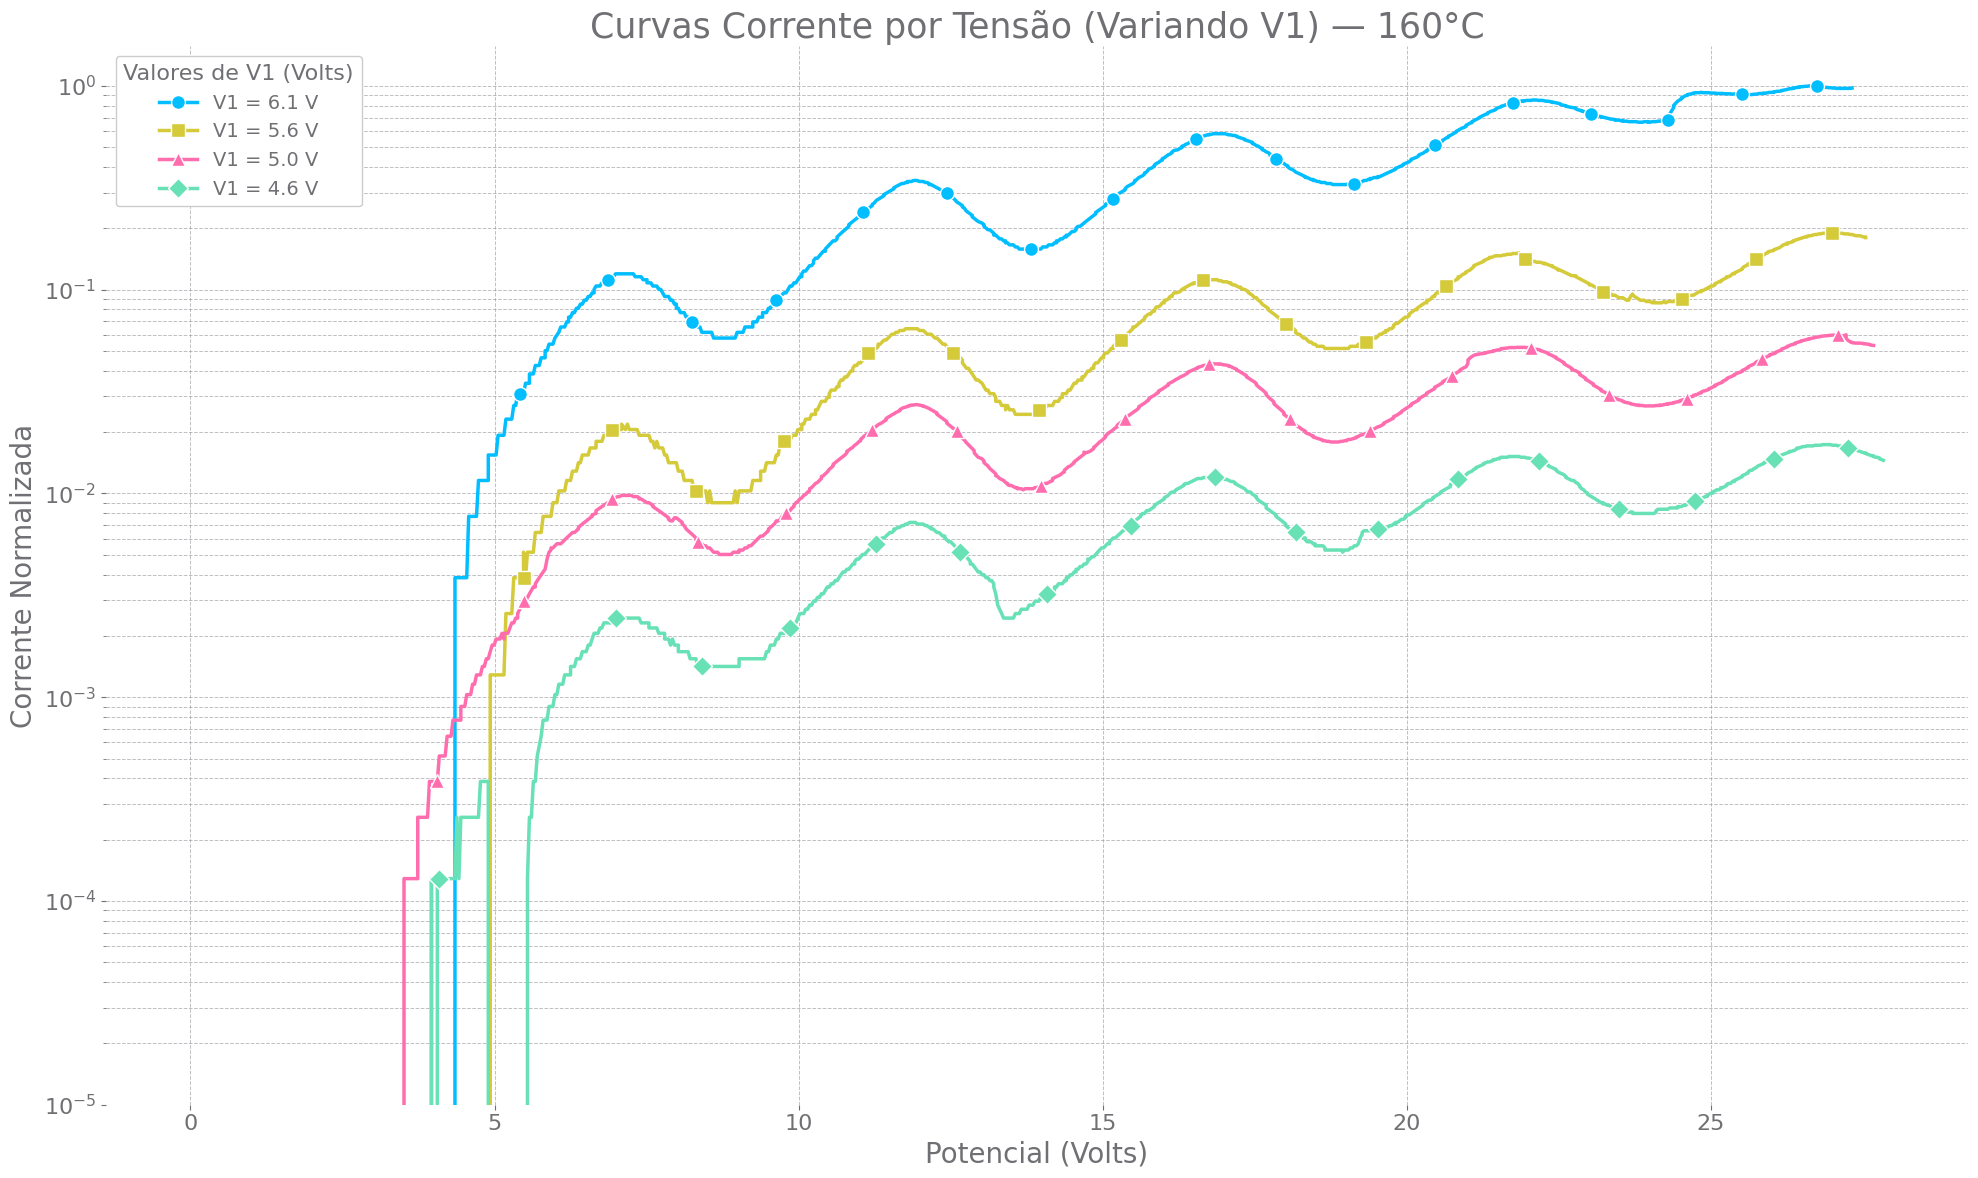

In [5]:
# Exemplo de uso:
gerar_graficos_franck_hertz(
    caminho_excel="Medidas Multiplas Excitações 140°C (Com fator de escala).xlsx",
    caminho_dados="Dados experimentais 23.10.2025 (Com fator de escala)/",
    caminho_saida="Resultados/",
    tipo="V1",
    temperatura=160,
    fator_dist=3,
    fator_prom=0.001,
    mostrar_deltas=False  # ativa as anotações ΔV
)